<a href="https://colab.research.google.com/github/asnaraliya/ICT/blob/main/supervisedlearningcasestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install xgboost


In [18]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, roc_auc_score


Load data

In [19]:
train_df = pd.read_csv("Training_data.csv")
test_df = pd.read_csv("Testing_data.csv")

print(train_df.head())
print(train_df.info())
print(train_df.isnull().sum())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  9509-MPYOD  Female              0      No         No      35          Yes   
1  7746-AWNQW  Female              0      No         No      28           No   
2  2208-UGTGR    Male              0      No         No      56          Yes   
3  4884-LEVMQ    Male              0     Yes         No      39          Yes   
4  6682-VCIXC  Female              0     Yes        Yes      43           No   

      MultipleLines InternetService       OnlineSecurity  ...  \
0                No              No  No internet service  ...   
1  No phone service             DSL                   No  ...   
2               Yes     Fiber optic                   No  ...   
3                No              No  No internet service  ...   
4  No phone service             DSL                  NaN  ...   

      DeviceProtection          TechSupport          StreamingTV  \
0  No internet service  No internet service  No internet ser

data preprocessing

In [20]:
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
train_df['TotalCharges'] = imputer.fit_transform(train_df[['TotalCharges']])

from sklearn.preprocessing import LabelEncoder
for col in train_df.select_dtypes(include=['object']).columns:
    if col not in ['customerID','Churn']:
        train_df[col] = LabelEncoder().fit_transform(train_df[col])


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_df[['MonthlyCharges','TotalCharges']] = scaler.fit_transform(train_df[['MonthlyCharges','TotalCharges']])


print("Missing values after preprocessing:\n", train_df.isnull().sum())


Missing values after preprocessing:
 customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges      394
TotalCharges          0
Churn                 0
dtype: int64


/tmp/ipykernel_1431/4054993837.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=train_df, palette='Set2')


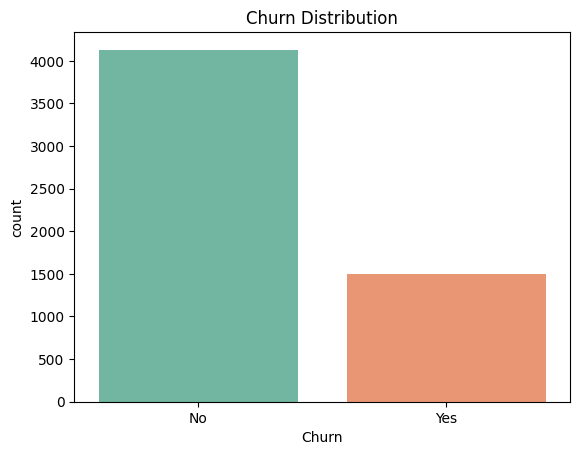

In [38]:
sns.countplot(x='Churn', data=train_df, palette='Set2')
plt.title("Churn Distribution")
plt.show()


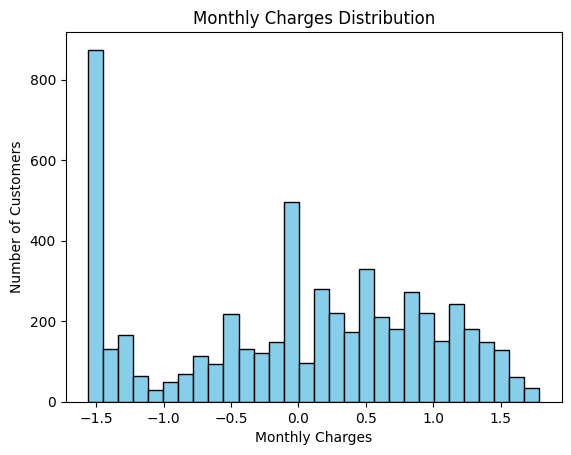

In [39]:
plt.hist(train_df['MonthlyCharges'], bins=30, color='skyblue', edgecolor='black')
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()


Feature engineering

In [22]:
train_df['CLV'] = train_df['tenure'] * train_df['MonthlyCharges']

service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
train_df['ServiceCount'] = train_df[service_cols].sum(axis=1)


print(train_df[['tenure','MonthlyCharges','CLV','ServiceCount']].head())


   tenure  MonthlyCharges        CLV  ServiceCount
0      35       -1.475766 -51.651819             6
1      28       -0.976658 -27.346412             4
2      56        1.114608  62.418036             6
3      39       -1.485748 -57.944189             6
4      43       -0.460912 -19.819214             9


/tmp/ipykernel_1431/4003408005.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ServiceCount', data=train_df, palette='viridis')


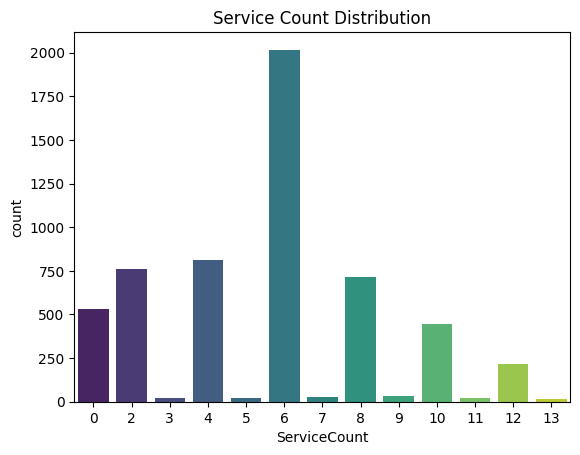

In [40]:
sns.countplot(x='ServiceCount', data=train_df, palette='viridis')
plt.title("Service Count Distribution")
plt.show()


/tmp/ipykernel_1431/2885193726.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='CLV', data=train_df, palette='Set1')


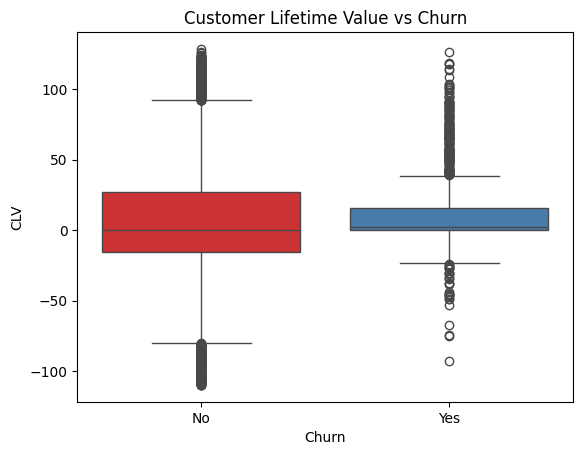

In [41]:
sns.boxplot(x='Churn', y='CLV', data=train_df, palette='Set1')
plt.title("Customer Lifetime Value vs Churn")
plt.show()


In [25]:
print("Missing values per column:\n", train_df.isnull().sum())


train_df = train_df.fillna(0)


print("Missing values after fillna:\n", train_df.isnull().sum())


Missing values per column:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
CLV                 0
ServiceCount        0
dtype: int64
Missing values after fillna:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
Total

Model development

In [27]:
X = train_df.drop(['Churn','customerID'], axis=1)
y = train_df['Churn'].map({'Yes':1,'No':0})

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear'),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)[:,1]

    print(f"\n{name}")
    print(classification_report(y_val, preds))
    print("ROC-AUC:", roc_auc_score(y_val, probs))



Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       826
           1       0.66      0.58      0.62       301

    accuracy                           0.81      1127
   macro avg       0.76      0.74      0.75      1127
weighted avg       0.80      0.81      0.80      1127

ROC-AUC: 0.8432384384577639

Random Forest
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       826
           1       0.64      0.51      0.57       301

    accuracy                           0.79      1127
   macro avg       0.74      0.70      0.72      1127
weighted avg       0.78      0.79      0.79      1127

ROC-AUC: 0.835141940102805

XGBoost
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       826
           1       0.61      0.49      0.54       301

    accuracy                           0.78      1127
   macro avg       0.72     

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:44:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


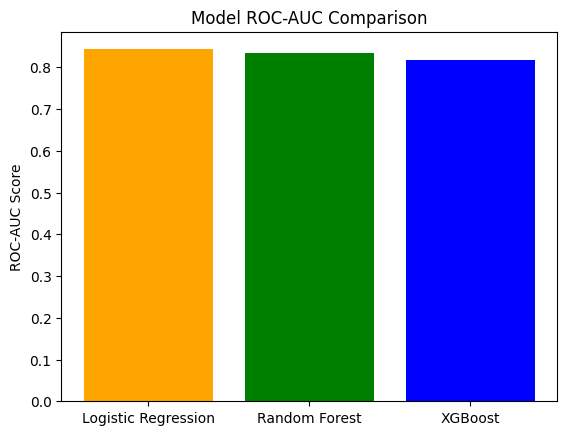

In [42]:
model_scores = {
    "Logistic Regression": roc_auc_score(y_val, models["Logistic Regression"].predict_proba(X_val)[:,1]),
    "Random Forest": roc_auc_score(y_val, models["Random Forest"].predict_proba(X_val)[:,1]),
    "XGBoost": roc_auc_score(y_val, models["XGBoost"].predict_proba(X_val)[:,1])
}

plt.bar(model_scores.keys(), model_scores.values(), color=['orange','green','blue'])
plt.title("Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC Score")
plt.show()


Hyper parameter tuning

In [29]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)


grid.fit(X_train, y_train)


print("Best parameters:", grid.best_params_)
print("Best ROC-AUC score:", grid.best_score_)


Best parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best ROC-AUC score: 0.8465546189675587


Prediction on testing

In [33]:
X_test = test_df.drop(['customerID','Churn'], axis=1, errors='ignore')

test_probs = best_model.predict_proba(X_test)[:,1]
test_preds = (test_probs >= 0.5).astype(int)


results = pd.DataFrame({
    'customerID': test_df['customerID'],
    'Churn_Predicted': test_preds,
    'Churn_Probability': test_probs
})

print(results.head())


   customerID  Churn_Predicted  Churn_Probability
0  6080-TCMYC                0           0.415448
1  7285-KLOTR                0           0.219531
2  7486-KSRVI                0           0.223804
3  9924-JPRMC                0           0.104723
4  4439-YRNVD                0           0.331216


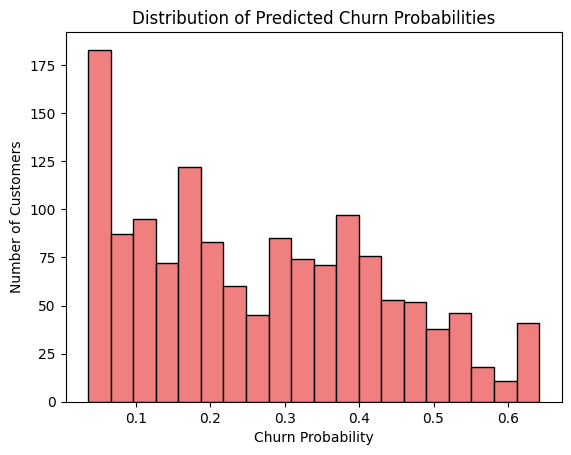

In [43]:
plt.hist(results['Churn_Probability'], bins=20, color='lightcoral', edgecolor='black')
plt.title("Distribution of Predicted Churn Probabilities")
plt.xlabel("Churn Probability")
plt.ylabel("Number of Customers")
plt.show()


In [35]:
results.to_csv("Churn_Predictions.csv", index=False)


from google.colab import files
files.download("Churn_Predictions.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Evaluation and visualization

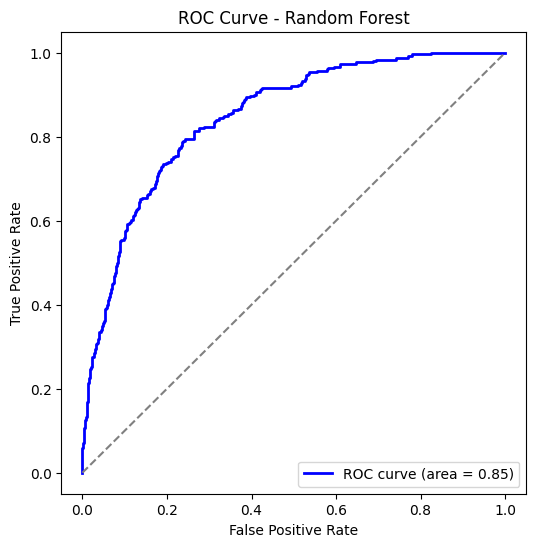

In [37]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_val, best_model.predict_proba(X_val)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()
